# Final Local + 60/40 Blend Rolling Stability

This notebook evaluates the final modeling recipe across historical rolling-origin cutoffs. For each cutoff, it retrains the same final model design on the prior 12-month window and evaluates on the next held-out month.

The goal is to answer: did the final Local + 60/40 Blend approach stay stable over time, or was the final June 2026 result unusually strong?

## 1. Setup

The notebook reuses the same helper functions, feature groups, XGBoost parameters, outlier filtering, local aggregate transformer, and blend weights used by `scripts/train_final_blend_model.py`.

In [1]:
from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from scripts.train_final_blend_model import (
    TARGET,
    apply_train_price_bounds,
    build_feature_groups,
    fit_target_mode,
    normalize_categorical_dtypes,
    regression_metrics,
)
from src.final_blend_model import FinalBlendPriceModel

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.4f}".format)

## 2. Load Data and Rolling Plan

The rolling plan comes from the existing split plan. The engineered full dataset is used so the final model can use the same engineered features as the final artifact.

In [2]:
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "week6_feature_engineering" / "crmls_week6_engineered.csv"
SPLIT_PLAN_PATH = PROJECT_ROOT / "data" / "processed" / "crmls_week3_split_plan.csv"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "final_blend_stability"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH, low_memory=False)
df = normalize_categorical_dtypes(df)
df["CloseDate"] = pd.to_datetime(df["CloseDate"], errors="coerce")
df["close_month"] = pd.PeriodIndex(df["close_month"], freq="M")

split_plan = pd.read_csv(SPLIT_PLAN_PATH, dtype={"split_type": "string", "eval_month": "string"})
rolling_plan = split_plan[split_plan["split_type"].isin(["historical_eval", "final_test"])].copy()
rolling_plan = rolling_plan.sort_values("eval_month").reset_index(drop=True)

display(rolling_plan)

,split_type,train_window_months,train_month_start,train_month_end,train_months,eval_month,train_rows,eval_rows
0,historical_eval,12,2024-09,2025-08,"2024-09, 2024-10, 2024-11, 2024-12, 2025-01, 2...",2025-09,130976,11449
1,historical_eval,12,2024-11,2025-10,"2024-11, 2024-12, 2025-01, 2025-02, 2025-03, 2...",2025-11,131211,9720
2,historical_eval,12,2025-01,2025-12,"2025-01, 2025-02, 2025-03, 2025-04, 2025-05, 2...",2026-01,130093,7485
3,historical_eval,12,2025-03,2026-02,"2025-03, 2025-04, 2025-05, 2025-06, 2025-07, 2...",2026-03,129139,11169
4,historical_eval,12,2025-05,2026-04,"2025-05, 2025-06, 2025-07, 2025-08, 2025-09, 2...",2026-05,129862,12014
5,final_test,12,2025-06,2026-05,"2025-06, 2025-07, 2025-08, 2025-09, 2025-10, 2...",2026-06,130114,12858


## 3. Train and Evaluate the Final Recipe by Cutoff

For each evaluation month:

- train on the planned 12-month historical window
- apply train-derived price and price-per-square-foot filters
- fit a local-aggregate XGBoost model on `log1p(ClosePrice)`
- fit a second local-aggregate XGBoost model on raw `ClosePrice`
- blend predictions as `60% log1p + 40% raw`
- record R², MAE, RMSE, MAPE, and MdAPE

This retraining step matters because the local price aggregate features must be fit only on each cutoff's training window.

In [3]:
def rows_for_months(data: pd.DataFrame, month_values: str) -> pd.DataFrame:
    months = [pd.Period(month.strip(), freq="M") for month in month_values.split(",")]
    return data[data["close_month"].isin(months)].copy()


def rows_for_eval_month(data: pd.DataFrame, eval_month: str) -> pd.DataFrame:
    return data[data["close_month"].eq(pd.Period(eval_month, freq="M"))].copy()


def evaluate_cutoff(plan_row: pd.Series) -> tuple[dict, pd.DataFrame]:
    eval_month = str(plan_row["eval_month"])
    train_raw = rows_for_months(df, str(plan_row["train_months"]))
    eval_raw = rows_for_eval_month(df, eval_month)
    train_df, eval_df, bound_info = apply_train_price_bounds(train_raw, eval_raw)

    numeric_cols, categorical_cols, boolean_cols, flag_cols, feature_cols = build_feature_groups(train_df)

    start_time = time.perf_counter()
    log1p_model, fit_seconds_log1p = fit_target_mode(
        train_df,
        feature_cols,
        numeric_cols,
        categorical_cols,
        boolean_cols,
        flag_cols,
        "log1p",
    )
    raw_model, fit_seconds_raw = fit_target_mode(
        train_df,
        feature_cols,
        numeric_cols,
        categorical_cols,
        boolean_cols,
        flag_cols,
        "raw",
    )

    artifact = FinalBlendPriceModel(
        log1p_model=log1p_model,
        raw_model=raw_model,
        feature_cols=feature_cols,
        numeric_cols=numeric_cols,
        categorical_cols=categorical_cols,
        boolean_cols=boolean_cols,
        flag_cols=flag_cols,
        log1p_weight=0.6,
        raw_weight=0.4,
        metadata={
            "model_name": "final_local_60_40_blend",
            "train_month_start": str(plan_row["train_month_start"]),
            "train_month_end": str(plan_row["train_month_end"]),
            "test_month": eval_month,
        },
    )

    predictions = artifact.predict(eval_df)
    metrics = regression_metrics(eval_df[TARGET], predictions)
    elapsed_seconds = time.perf_counter() - start_time

    result = {
        "model_name": "final_local_60_40_blend",
        "eval_month": eval_month,
        "train_month_start": str(plan_row["train_month_start"]),
        "train_month_end": str(plan_row["train_month_end"]),
        "train_window_months": int(plan_row["train_window_months"]),
        "log1p_weight": artifact.log1p_weight,
        "raw_weight": artifact.raw_weight,
        "n_raw_features": len(feature_cols),
        "fit_seconds_log1p": fit_seconds_log1p,
        "fit_seconds_raw": fit_seconds_raw,
        "elapsed_seconds": elapsed_seconds,
        **bound_info,
        **metrics,
    }

    prediction_detail = eval_df[["ListingKey", "close_month", TARGET, "LivingArea", "PostalCode", "CountyOrParish", "UnifiedSchoolDistrict"]].copy()
    prediction_detail["prediction"] = predictions
    prediction_detail["absolute_error"] = (prediction_detail[TARGET] - prediction_detail["prediction"]).abs()
    prediction_detail["absolute_percentage_error"] = prediction_detail["absolute_error"] / prediction_detail[TARGET] * 100
    prediction_detail["eval_month"] = eval_month
    return result, prediction_detail


results = []
prediction_details = []

for _, plan_row in rolling_plan.iterrows():
    print(f"Training final blend recipe for eval month {plan_row['eval_month']}...")
    result, prediction_detail = evaluate_cutoff(plan_row)
    results.append(result)
    prediction_details.append(prediction_detail)
    print(
        f"  R2={result['r2']:.4f}, MAPE={result['mape']:.2f}%, "
        f"MdAPE={result['mdape']:.2f}%, MAE=${result['mae']:,.0f}"
    )

results_df = pd.DataFrame(results)
predictions_df = pd.concat(prediction_details, ignore_index=True)

display(results_df[["eval_month", "r2", "mae", "rmse", "mape", "mdape", "eval_rows_after_filter", "elapsed_seconds"]])

Training final blend recipe for eval month 2025-09...


  R2=0.9120, MAPE=10.64%, MdAPE=7.28%, MAE=$132,065
Training final blend recipe for eval month 2025-11...


  R2=0.9222, MAPE=10.54%, MdAPE=7.21%, MAE=$131,782
Training final blend recipe for eval month 2026-01...


  R2=0.9066, MAPE=11.11%, MdAPE=7.23%, MAE=$135,965
Training final blend recipe for eval month 2026-03...


  R2=0.9176, MAPE=10.33%, MdAPE=7.22%, MAE=$135,025
Training final blend recipe for eval month 2026-05...


  R2=0.9097, MAPE=10.54%, MdAPE=7.27%, MAE=$143,538
Training final blend recipe for eval month 2026-06...


  R2=0.9159, MAPE=10.43%, MdAPE=7.27%, MAE=$141,558


,eval_month,r2,mae,rmse,mape,mdape,eval_rows_after_filter,elapsed_seconds
0,2025-09,0.9120,132064.7869,259215.1970,10.6398,7.2828,11172,15.1829
1,2025-11,0.9222,131781.5014,251336.3835,10.5403,7.2123,9464,15.5769
2,2026-01,0.9066,135964.6073,274445.5869,11.1099,7.2272,7290,15.0549
3,2026-03,0.9176,135024.9386,260632.2177,10.3348,7.2204,10877,14.9309
4,2026-05,0.9097,143537.7747,283415.4423,10.5434,7.2665,11719,15.1928
5,2026-06,0.9159,141558.2646,277507.0904,10.4312,7.2740,12538,15.1405


## 4. Save Results

In [4]:
results_path = OUTPUT_DIR / "final_blend_rolling_origin_results.csv"
predictions_path = OUTPUT_DIR / "final_blend_rolling_origin_predictions.csv"

results_df.to_csv(results_path, index=False)
predictions_df.to_csv(predictions_path, index=False)

print(f"Saved rolling results: {results_path.relative_to(PROJECT_ROOT)}")
print(f"Saved prediction detail: {predictions_path.relative_to(PROJECT_ROOT)}")

Saved rolling results: outputs/final_blend_stability/final_blend_rolling_origin_results.csv
Saved prediction detail: outputs/final_blend_stability/final_blend_rolling_origin_predictions.csv


## 5. Stability Summary

In [5]:
summary = pd.DataFrame([
    {
        "model_name": "final_local_60_40_blend",
        "n_cutoffs": results_df["eval_month"].nunique(),
        "mean_r2": results_df["r2"].mean(),
        "std_r2": results_df["r2"].std(),
        "min_r2": results_df["r2"].min(),
        "max_r2": results_df["r2"].max(),
        "mean_mae": results_df["mae"].mean(),
        "mean_rmse": results_df["rmse"].mean(),
        "mean_mape": results_df["mape"].mean(),
        "mean_mdape": results_df["mdape"].mean(),
        "std_mdape": results_df["mdape"].std(),
        "min_mdape": results_df["mdape"].min(),
        "max_mdape": results_df["mdape"].max(),
    }
])

summary_path = OUTPUT_DIR / "final_blend_rolling_origin_summary.csv"
summary.to_csv(summary_path, index=False)

display(summary)
print(f"Saved rolling summary: {summary_path.relative_to(PROJECT_ROOT)}")

,model_name,n_cutoffs,mean_r2,std_r2,min_r2,max_r2,mean_mae,mean_rmse,mean_mape,mean_mdape,std_mdape,min_mdape,max_mdape
0,final_local_60_40_blend,6,0.9140,0.0057,0.9066,0.9222,136655.3123,267758.6529,10.5999,7.2472,0.0306,7.2123,7.2828


Saved rolling summary: outputs/final_blend_stability/final_blend_rolling_origin_summary.csv


## 6. Stability Charts

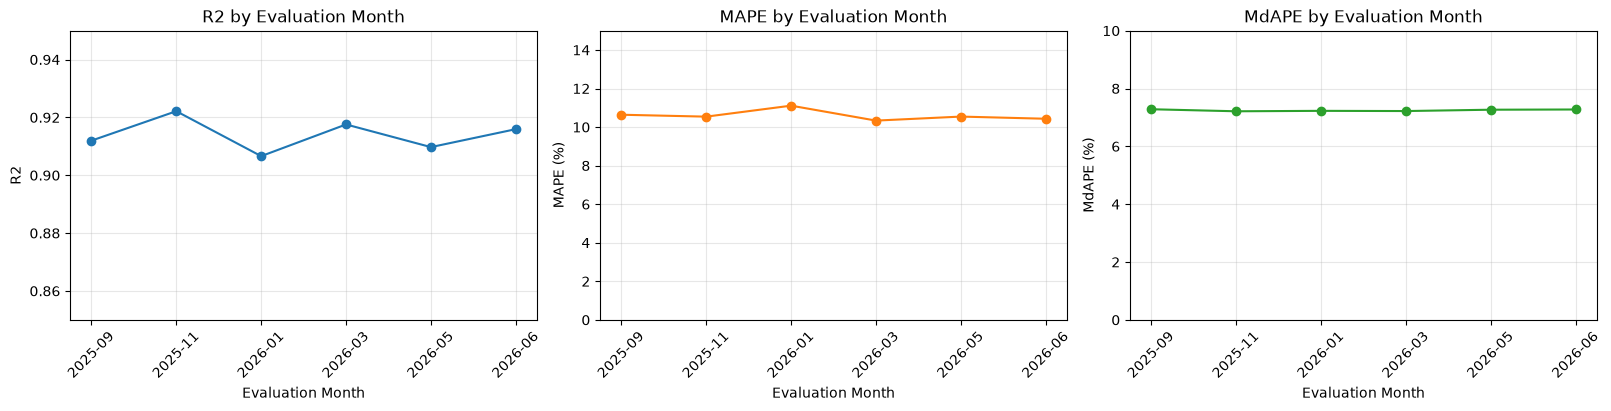

In [6]:
plot_df = results_df.sort_values("eval_month").copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)

axes[0].plot(plot_df["eval_month"], plot_df["r2"], marker="o")
axes[0].set_title("R2 by Evaluation Month")
axes[0].set_xlabel("Evaluation Month")
axes[0].set_ylabel("R2")
axes[0].set_ylim(0.85, 0.95)
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis="x", rotation=45)

axes[1].plot(plot_df["eval_month"], plot_df["mape"], marker="o", color="tab:orange")
axes[1].set_title("MAPE by Evaluation Month")
axes[1].set_xlabel("Evaluation Month")
axes[1].set_ylabel("MAPE (%)")
axes[1].set_ylim(0, 15)
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis="x", rotation=45)

axes[2].plot(plot_df["eval_month"], plot_df["mdape"], marker="o", color="tab:green")
axes[2].set_title("MdAPE by Evaluation Month")
axes[2].set_xlabel("Evaluation Month")
axes[2].set_ylabel("MdAPE (%)")
axes[2].set_ylim(0, 10)
axes[2].grid(True, alpha=0.3)
axes[2].tick_params(axis="x", rotation=45)

plt.show()

## 7. Presentation-Ready Table

In [7]:
presentation_table = results_df[["eval_month", "r2", "mape", "mdape", "mae", "rmse"]].copy()
presentation_table["R2"] = presentation_table["r2"].map(lambda x: f"{x:.3f}")
presentation_table["MAPE"] = presentation_table["mape"].map(lambda x: f"{x:.2f}%")
presentation_table["MdAPE"] = presentation_table["mdape"].map(lambda x: f"{x:.2f}%")
presentation_table["MAE"] = presentation_table["mae"].map(lambda x: f"${x:,.0f}")
presentation_table["RMSE"] = presentation_table["rmse"].map(lambda x: f"${x:,.0f}")
presentation_table = presentation_table[["eval_month", "R2", "MAPE", "MdAPE", "MAE", "RMSE"]]

display(presentation_table)

,eval_month,R2,MAPE,MdAPE,MAE,RMSE
0,2025-09,0.912,10.64%,7.28%,"$132,065","$259,215"
1,2025-11,0.922,10.54%,7.21%,"$131,782","$251,336"
2,2026-01,0.907,11.11%,7.23%,"$135,965","$274,446"
3,2026-03,0.918,10.33%,7.22%,"$135,025","$260,632"
4,2026-05,0.910,10.54%,7.27%,"$143,538","$283,415"
5,2026-06,0.916,10.43%,7.27%,"$141,558","$277,507"


## 8. Suggested Interpretation

Use the saved summary and table above to describe whether the final recipe held steady across time. If R² and MdAPE stay close across cutoffs, the presentation takeaway can be that the final model is not only strong on the final June 2026 holdout, but also reasonably stable across prior evaluation months.

If one month is noticeably worse, inspect that month separately and explain it as possible market shift, seasonality, sample composition, or a higher share of unusual/luxury properties.